# Partie 1

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
x_true = pd.read_table('x.txt',header=None,names=['x'])
N = 200
T_min, T_max = 1,1000
T = np.array([T_min * np.exp(np.log(T_max/T_min)*i/(N-1)) for i in range(N)])

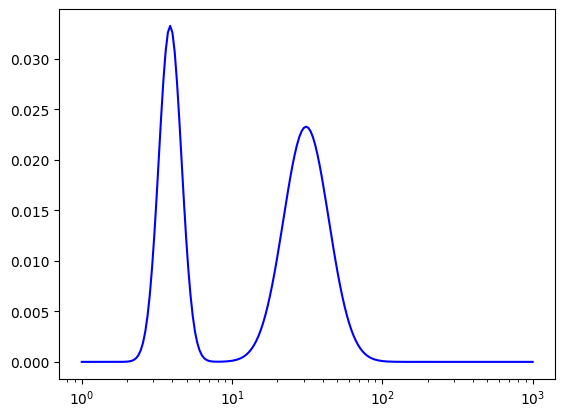

In [4]:
plt.plot(T,x_true.x, label='True', color='blue')
plt.xscale('log')

In [5]:
M = 50
tmin, tmax = 0,1.5
t = np.array([tmin + (tmax - tmin)*i/(M-1) for i in range(M)])
K = np.exp(-np.outer(t,T))

In [6]:
z = K@x_true.x
sigma = 0.01 * z[0]
w = np.random.normal(loc=np.zeros(M), scale=sigma,size=(M,))
y = z + w

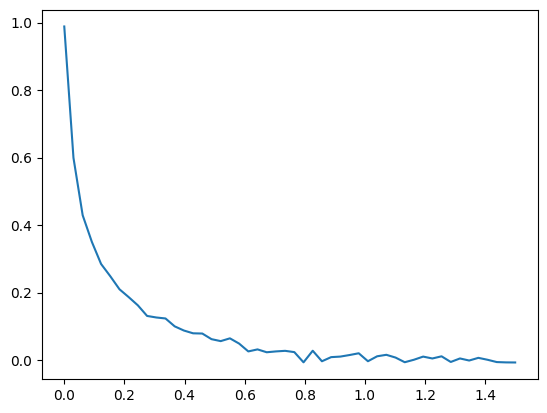

In [7]:
plt.plot(t, y)

smootheness prior

On est dans le cas où f et g sont toutes les deux convexes et différentiables. On s'apercevant que les gradients s'expriment aisément en fonction des matrices D, K et du paramètre $\beta$, on peut simplement inverser le système matriciel. On pourrait également faire une descente de gradient ou utiliser les algorithmes forward-backward et Douglas-Racheford car les fonctions sont proximables.
$$\nabla f(\mathbf{x}) = \mathbf{K}^\top \mathbf{K} \mathbf{x} - \mathbf{K}^\top \mathbf{y}$$
$$\nabla g(\mathbf{x}) = \beta \mathbf{D}^\top \mathbf{D} \mathbf{x} $$
On cherche donc x vérifiant : 
$$\mathbf{x} = (\mathbf{K}^\top \mathbf{K} + \beta \mathbf{D}^\top \mathbf{D})^{-1} \mathbf{K}^\top \mathbf{y}$$
A condition que $\mathbf{K}^\top \mathbf{K} + \beta \mathbf{D}^\top \mathbf{D}$ soit inversible. Comme $\mathbf{K}^\top \mathbf{K}$ et $\beta \mathbf{D}^\top \mathbf{D}$ sont semi-définies positives et que le noyau de D ne contient que les vecteurs constants et que K n'annule pas les constantes, la matrice est bien inversible.

Best beta: 1.0
Minimum NQE: 0.42645857362700657


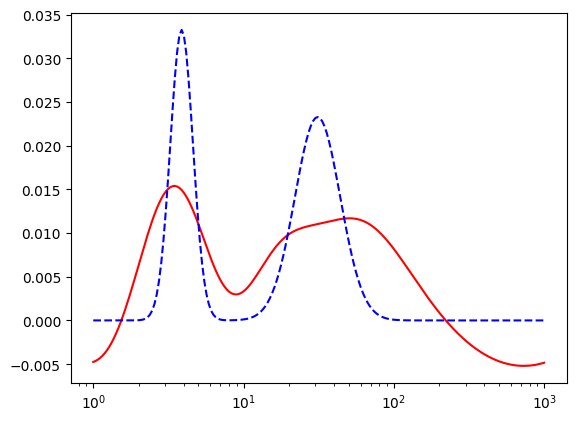

In [8]:
D = np.identity(N,dtype=float)
for i in range(1,N):
    D[i,i-1] = -1.0
D[0,N-1] = -1.0
#cas inversible simple, annulation du gradient pour minimiser la fonction
def solve_min(K, D, y, beta):
    A = K.T @ K + beta * (D.T @ D)
    b = K.T @ y
    return np.linalg.solve(A, b)

grid_beta = np.linspace(-2,2,9)
NQE_list = [] 
for beta in grid_beta:
    res = solve_min(K, D, y, beta)
    NQE = np.sum(((res - x_true.x)**2))/np.sum((x_true.x**2))
    NQE_list.append(NQE)

best_beta = grid_beta[np.argmin(NQE_list)]
res = solve_min(K, D, y, 1)
print("Best beta:", best_beta)
print("Minimum NQE:", np.min(NQE_list))
plt.plot(T, res, label='Reconstructed', color='red')
plt.plot(T, x_true.x, label='Original', color='blue', linestyle='dashed')
plt.xscale('log')
plt.show()

In [9]:
# La solution n'est pas optimale, il ne s'agit que d'une approximation de la solution. 
print(K.T @ K + beta * (D.T @ D) @res == K.T @ y)

[[False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]
 ...
 [False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]]


Comme $f+g$ est convexe, propre, semi-continue inférieure, et qu'on peut estimer sa constante de lipschitz (plus grande valeur propre de $(\mathbf{K}^\top \mathbf{K} + \beta \mathbf{D}^\top \mathbf{D})$), on peut faire une descente de gradient. Pour assurer l'unicité de la solution, il faut que $f+g$ soit strictement convexe ce qui est le cas puisque $(\mathbf{K}^\top \mathbf{K} + \beta \mathbf{D}^\top \mathbf{D})$ est inversible.

Smootheness prior + constraint :

Cette fois ci g n'est plus différentiable et on ne peut plus inverser le système simplement. Comme la fonction indicatrice est proximable on peut utiliser l'algorithme forward-backward qui nous assure la convergence vers un minimum de $f+g$. La partie convexe différentiable étant strictement convexe la solution est unique.

Best beta: 0.01
Minimum NQE: 0.08291880683155368


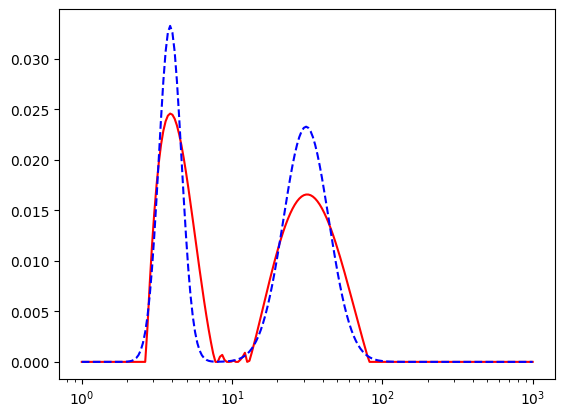

In [18]:
def g1(x):
    return np.sum((D @ x)**2)/2

x_min, x_max = min(x_true.x), max(x_true.x)
x_init = np.mean(x_true.x)*np.ones(N)
def g2(x):
    for i in range(len(x)):
        if x[i] < x_min or x[i] > x_max:
            return np.inf
    return g1(x)

def f(x):
    Kx = K @ x
    return 0.5*np.sum((Kx - y)**2)

from scipy.optimize import minimize
grid_beta = np.logspace(-2,2,10)
NQE_list = [] 

## Naive optimization
for beta in grid_beta:
    res = minimize(lambda x: f(x) + beta*g1(x), x0=0.1*np.ones(N), method='L-BFGS-B',bounds=[(x_min, x_max)]*N)
    NQE = np.sum(((res.x - x_true.x)**2)/np.sum(x_true.x**2))
    NQE_list.append(NQE)
#gradient inexistant donc refuge dans solution de départ car g2 pas diff partout
best_beta = grid_beta[np.argmin(NQE_list)]
res = minimize(lambda x: f(x) + best_beta*g1(x), x0=0.1*np.ones(N), method='L-BFGS-B',bounds=[(x_min, x_max)]*N)
print("Best beta:", best_beta)
print("Minimum NQE:", np.min(NQE_list))
plt.plot(T, res.x, label='Reconstructed', color='red')
plt.plot(T, x_true.x, label='Original', color='blue', linestyle='dashed')
plt.xscale('log')
plt.show()


NQE Forward-Backward: 0.05304377434557363


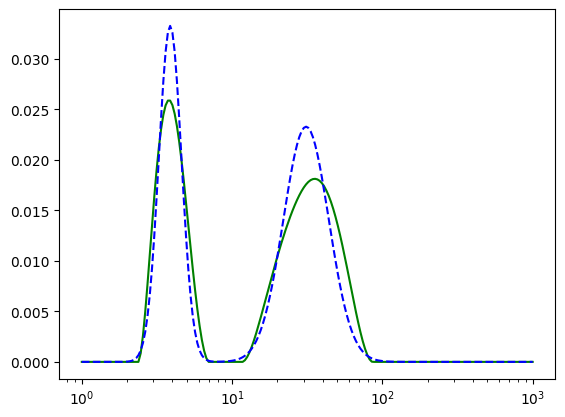

In [10]:
## Forward - Backward optimization
import numpy as np
def proximal_indicator(v): #projection sur l'ensemble [x_min, x_max]^N
    x = np.minimum(np.maximum(v, x_min), x_max)
    return x

def forward_backward_optimization(beta, K, y, max_iter=1000,x_init=x_init):
    x_curr = x_init.copy()
    # lipschitz_const = np.linalg.norm(K, ord=2)**2 + beta * np.linalg.norm(D, ord=2)**2 #borne sup de la constante de Lipschitz du gradient de f + beta*g1
    # lipschitz_const = np.linalg.eigvalsh(K.T @ K).max() + beta * np.linalg.eigvalsh(D.T @ D).max()
    lipschitz_const = np.linalg.eigvalsh(K.T @ K + beta * D.T @ D).max()
    gamma = 1 / lipschitz_const
    delta = 2 - 2 * gamma * lipschitz_const/2
    lambda_curr = delta 

    for _ in range(max_iter):
        # Forward
        y_curr = x_curr - gamma * (K.T @ (K @ x_curr - y) + beta * (D.T @ D) @ x_curr)
        # Backward
        x_next = x_curr + lambda_curr * (proximal_indicator(y_curr) - x_curr)

        x_curr = x_next

    return x_curr

res_fb = forward_backward_optimization(0.6, K, y, max_iter=200000)
NQE_fb = np.sum(((res_fb - x_true.x)**2)/np.sum((x_true.x**2)))
print("NQE Forward-Backward:", NQE_fb) 
plt.plot(T, res_fb, label='Reconstructed FB', color='green')
plt.plot(T, x_true.x, label='Original', color='blue', linestyle='dashed')
plt.xscale('log')
plt.show()

### Sparsity
Comme g n'est pas différentiable mais proximable, on utilise Douglas Racheford.

fin


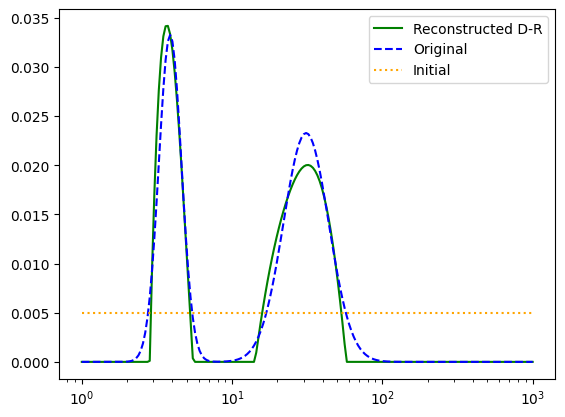

In [ ]:
def prox_f(v, gamma, K, y):
    A = gamma * K.T @ K + np.eye(K.shape[1])
    rhs = gamma *K.T @ y +  v
    x = np.linalg.solve(A, rhs)
    return x

def prox_l1_vec(v, gamma):
    return np.sign(v) * np.maximum(np.abs(v) - gamma, 0.0)


def douglas_rachford(K, y, beta, gamma,x0=x_init, n_iter=200, lamb=1, tol=1e-6):
    xn = x0.copy()
    yn_list = []
    zn_list = []
    xn_list = []
    for n in range(n_iter):      
        tau = gamma * beta
        yn = prox_l1_vec(xn, tau)
        yn_list.append(yn)

        arg = 2.0 * yn - xn
        zn = prox_f(arg, gamma, K, y)
        zn_list.append(zn)

        xn1 = xn + lamb * (zn - yn)
        xn_list.append(xn1)

        resid = np.linalg.norm(xn1 - xn)
        if resid < tol:
            xn = xn1
            print(f'Converged in {n} iterations.')
            break

        xn = xn1

    x_est = prox_l1_vec(xn, tau) 
    return x_est, yn_list, zn_list, xn_list

x_sol, yn_list, zn_list, xn_list = douglas_rachford(K, y, beta = 0.05, gamma = 0.06, n_iter=1500, lamb = 1, tol=1e-6) 
print("fin")

plt.plot(T, x_sol, label='Reconstructed D-R', color='green')
plt.plot(T, x_true.x, label='Original', color='blue', linestyle='dashed')
plt.plot(T, x_init, label='Initial', color='orange', linestyle='dotted')
plt.legend()
plt.xscale('log')
plt.show()
#avec x_true beta = 0.05, gamma = 0.001

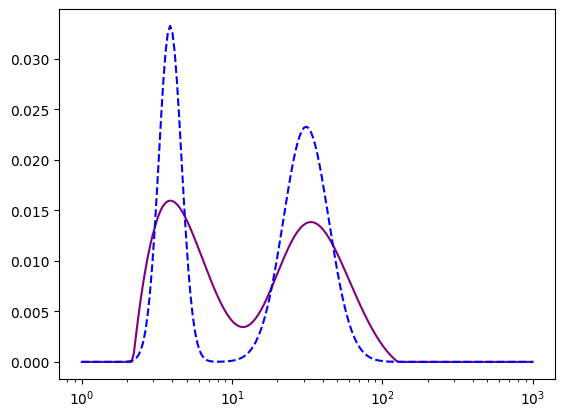

In [12]:
D = np.zeros((N-1,N))
for i in range(N-1):
    D[i,i] = -1
    D[i,i+1] = 1 
def grad(x, beta, K, y):
    return K.T @ (K @ x - y) + beta * D.T @ (D @ x)
def gradient_descent(K, y, beta, x0, n_iter=200, tol=1e-6, clipping=True):
    xn = x0.copy()
    yn = xn
    gamma = 2 / (np.linalg.norm(K, ord=2)**2 + beta * np.linalg.norm(D, ord=2)**2)
    lamb = 1.0
    for n in range(n_iter):
        grad_xn = grad(xn, beta, K, y)
        if clipping:
            yn = xn - gamma * grad_xn
            xn1 = xn + lamb * (np.clip(yn, 0, 1e3) - xn)
        else:
            xn1 = xn - gamma * grad_xn
        resid = np.linalg.norm(xn1 - xn)
        if resid < tol:
            xn = xn1
            break
        xn = xn1
    return xn

x0 = np.zeros(N)
x_sol = gradient_descent(K, y, beta = 10e-5, x0 = x0, n_iter=20000, tol=1e-6, clipping=True) 
plt.plot(T, x_sol, label='Reconstructed GD', color='purple')
plt.plot(T, x_true.x, label='Original', color='blue', linestyle='dashed')
plt.xscale('log')
plt.show()


# Partie 2

### 1)
$\varphi$ est propre ($dom(\varphi = [0,+\inf[)$), semi-continue inférieure car continue sur $[0,+\inf[$ (prolongement par continué $\lim\limits{u \rightarrow 0} u \log{u}$), continue sur $[-\inf,0[$ et on vérifie sans peine que la limite inférieure en 0 de $\varphi$ qui vaut $+\inf$ est bien supérieure à $\varphi(0)$.
Sur $]0,+\inf[ \varphi$ est convexe car sa dérivée seconde $u \mapsto \frac{1}{u}$ est postitive. En distinguant les cas où x et y sont positifs et négatifs, on montre ensuite aisément l'inégalité vérifié par une fonction convexe. 
$$ \forall x,y \in \mathbb{R} , \forall \alpha \in [0,1] f(\alpha x + (1-\alpha)y) \leq \alpha f(x) + (1-\alpha)f(y)$$
Donc $\varphi$ est bien convexe sur $\mathbb{R}$.
Comme $ent(x)$ est la somme séparable de fonctions propres, semi-continues inférieures et convexes elle est propre, semi-continue inférieure et convexe.

### 2)
$f(x)$ est strictement convexe sur $\mathbb{R}$ car $\mathbf{K}$ est de rang plein (on reconnaît une matrice de Vandermonde, les $T^{(m)}$ étant 2 à 2 distincts, elle est pleine.) et ent(x) est convexe donc la fonction objective est strictement convexe et propre donc le problème admet une unique solution.

### 3)

$$
\operatorname{prox}_{\varphi}(x)
= \arg\min_{y \in \mathbb{R}} \left( y\log y + \frac{1}{2}(y-x)^2 \right)
= \arg\min_{y \in \mathbb{R}} h(y)
$$

$$
h'(y) = \log(y) + 1 + y - x
$$

En composant avec l'exponentielle, on fait apparaître la fonction de Lambert :
$$
y \exp(y) = \exp(x-1)
\quad \text{et} \quad
y = W(\exp(x-1)).
$$

Le proximal de $\mathrm{ent}(x)$ se calcule aisément :
$$
\operatorname{prox}_{\mathrm{ent}}(x)
= \bigl(\operatorname{prox}_{\varphi}(x^{i})\bigr)_{i=1}^{N}
= \bigl(W(\exp(x^{i}-1))\bigr)_{i=1}^{N}.
$$

Et on trouve :
$$
\forall \gamma \in (0,+\infty), \qquad
\operatorname{prox}_{\gamma\,\mathrm{ent}}(x)
= \biggl(\gamma\, W\!\left(\frac{1}{\gamma}
\exp\!\left(\frac{x^{i}}{\gamma}-1\right)\right)\biggr)_{i=1}^{N}.
$$


### 4) Forward-Backward

Converged in 23 iterations.
NQE Forward-Backward: 0.7624176280644355


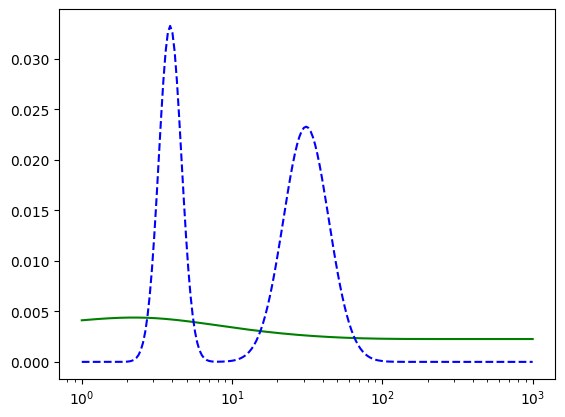

In [20]:
from scipy.special import lambertw

def prox_ent(x,gamma):
    """Proximal operator of the entropy function"""
    return np.real(gamma*lambertw(np.exp((x/gamma - 1)))) #np.real(gamma*lambertw(np.exp((x/gamma - 1)/gamma)))

def forward_backward_optimization(beta, K, y, max_iter=1000,x_init=x_init, tol=1e-6):
    x_curr = x_init.copy()
    # lipschitz_const = np.linalg.norm(K, ord=2)**2 + beta * np.linalg.norm(D, ord=2)**2 #borne sup de la constante de Lipschitz du gradient de f + beta*g1
    # lipschitz_const = np.linalg.eigvalsh(K.T @ K).max() + beta * np.linalg.eigvalsh(D.T @ D).max()
    lipschitz_const = np.linalg.eigvalsh(K.T @ K).max()
    gamma = 2 / lipschitz_const
    delta = 2 -  gamma * lipschitz_const/2
    lambda_curr = delta/2 

    for _ in range(max_iter):
        # Forward
        y_curr = x_curr - gamma * (K.T @ (K @ x_curr - y))
        # Backward
        x_next = x_curr + lambda_curr * (prox_ent(y_curr, gamma) - x_curr)
        resid = np.linalg.norm(x_next - x_curr)
        if resid < tol:
            x_curr = x_next
            print(f'Converged in {_} iterations.')
            break

        x_curr = x_next

    return x_curr

res_fb = forward_backward_optimization(0.01, K, y, max_iter=2000)
NQE_fb = np.sum(((res_fb - x_true.x)**2)/np.sum((x_true.x**2)))
print("NQE Forward-Backward:", NQE_fb) 
plt.plot(T, res_fb, label='Reconstructed FB', color='green')
plt.plot(T, x_true.x, label='Original', color='blue', linestyle='dashed')
plt.xscale('log')
plt.show()

Converged in 30 iterations.
Converged in 30 iterations.
Converged in 30 iterations.
Converged in 30 iterations.
Converged in 30 iterations.
Converged in 30 iterations.
Converged in 30 iterations.
Converged in 30 iterations.
Converged in 30 iterations.
Converged in 30 iterations.
Converged in 30 iterations.
Best beta: 0.0001
Minimum NQE: 0.763727003077379


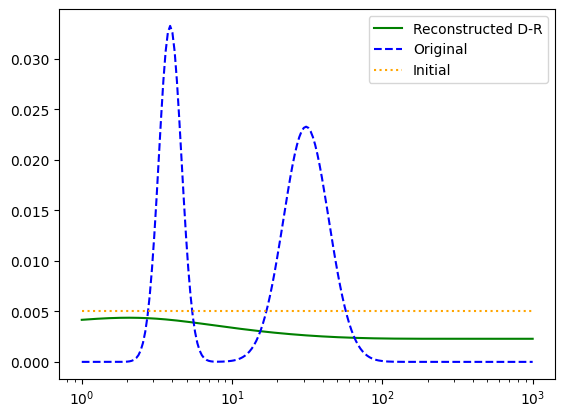

In [150]:
grid_beta = np.logspace(-4,0,10)
NQE_list = [] 

## Naive optimization
for beta in grid_beta:
    res = forward_backward_optimization(beta, K, y, max_iter=1000,x_init=x_init, tol=1e-7)
    NQE = np.sum(((res - x_true.x)**2)/np.sum(x_true.x**2))
    NQE_list.append(NQE)
#gradient inexistant donc refuge dans solution de départ car g2 pas diff partout
best_beta = grid_beta[np.argmin(NQE_list)]
res = forward_backward_optimization(best_beta, K, y, max_iter=1000,x_init=x_init, tol=1e-7)
print("Best beta:", best_beta)
print("Minimum NQE:", np.min(NQE_list))
    
plt.plot(T, res, label='Reconstructed D-R', color='green')
plt.plot(T, x_true.x, label='Original', color='blue', linestyle='dashed')
plt.plot(T, x_init, label='Initial', color='orange', linestyle='dotted')
plt.legend()
plt.xscale('log')
plt.show()

### 4) Douglas Rachford

Converged in 180 iterations.
fin


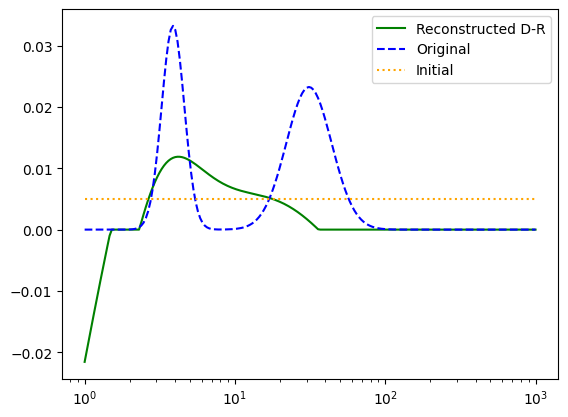

In [133]:
from scipy.special import lambertw

def prox_ent(x,gamma):
    """Proximal operator of the entropy function"""
    return np.real(gamma*lambertw(np.exp((x/gamma - 1)))) #np.real(gamma*lambertw(np.exp((x/gamma - 1)/gamma)))


def douglas_rachford(K, y, beta, gamma,x0=x_init, n_iter=200, lamb=1, tol=1e-6):
    xn = x0.copy()
    for n in range(n_iter):      
        tau = gamma * beta
        yn = prox_ent(xn, tau)

        arg = 2.0 * yn - xn
        zn = prox_f(arg, gamma, K, y)

        xn1 = xn + lamb * (zn - yn)

        resid = np.linalg.norm(xn1 - xn)
        if resid < tol:
            xn = xn1
            print(f'Converged in {n} iterations.')
            break

        xn = xn1

    x_est = prox_l1_vec(xn, tau) 
    return x_est

x_sol = douglas_rachford(K, y, beta = 0.01, gamma = 1, n_iter=2000, lamb = 2, tol=1e-6) 
print("fin")

plt.plot(T, x_sol, label='Reconstructed D-R', color='green')
plt.plot(T, x_true.x, label='Original', color='blue', linestyle='dashed')
plt.plot(T, x_init, label='Initial', color='orange', linestyle='dotted')
plt.legend()
plt.xscale('log')
plt.show()


Converged in 356 iterations.
Converged in 128 iterations.
Converged in 95 iterations.
Converged in 159 iterations.
Converged in 349 iterations.
Converged in 653 iterations.
Best beta: 0.0002782559402207126
Minimum NQE: 0.109335169512622


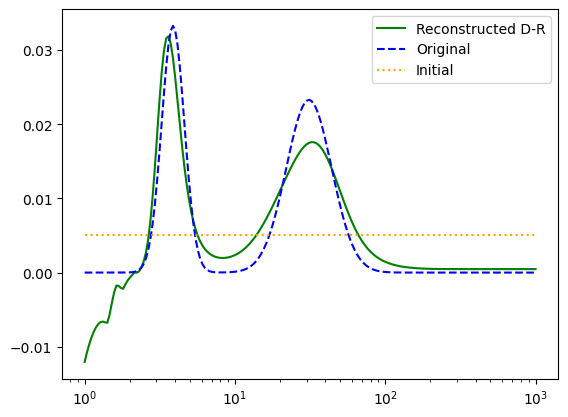

In [136]:
grid_beta = np.logspace(-4,0,10)
NQE_list = [] 

## Naive optimization
for beta in grid_beta:
    res = douglas_rachford(K, y, beta = beta, gamma = 1, n_iter=2000, lamb = 2, tol=1e-6)
    NQE = np.sum(((res - x_true.x)**2)/np.sum(x_true.x**2))
    NQE_list.append(NQE)
#gradient inexistant donc refuge dans solution de départ car g2 pas diff partout
best_beta = grid_beta[np.argmin(NQE_list)]
res = douglas_rachford(K, y, beta = best_beta, gamma = 1, n_iter=2000, lamb = 2, tol=1e-6)
print("Best beta:", best_beta)
print("Minimum NQE:", np.min(NQE_list))
    
plt.plot(T, res, label='Reconstructed D-R', color='green')
plt.plot(T, x_true.x, label='Original', color='blue', linestyle='dashed')
plt.plot(T, x_init, label='Initial', color='orange', linestyle='dotted')
plt.legend()
plt.xscale('log')
plt.show()

### 8)
L'équation : 
$$
\min_{x \in \mathbb{R}^N} \ \mathrm{ent}(x)
\quad \text{subject to} \quad
\|Kx - y\|_2 \le \eta\, M\, \sigma^2 .
$$
est équivalente à :
$$
\min_{x \in \mathbb{R}^N} \ \mathrm{ent}(x) + \mathrm{l}_{]-\inf,\eta\, M\, \sigma^2]}(\|Kx - y\|_2)
$$
Et la fonction indicatrice étant